# LangChain RAG Walkthrough with ChromaDB

This notebook demonstrates a complete Retrieval-Augmented Generation (RAG) implementation using:
- **LangChain** for orchestration
- **ChromaDB** as the vector store (ephemeral, no background processes)
- **Flexible LLM support** for OpenAI, Gemini, or Ollama
- **Document chunking** and **embedding** workflows
- **Similarity-based retrieval**

## Overview
1. Setup and Dependencies
2. Document Loading and Chunking
3. Embedding Generation
4. Vector Store Creation (ChromaDB)
5. Similarity Retrieval
6. LLM Integration (OpenAI/Gemini/Ollama)
7. Complete RAG Pipeline

In [ ]:
# Install required packages
!pip install langchain langchain-community langchain-openai langchain-google-genai chromadb sentence-transformers pypdf2 python-dotenv bs4 langchain-ollama

In [8]:
# Import required libraries

import os
from typing import List, Optional
from dotenv import load_dotenv

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document
from langchain_community.vectorstores import Chroma
from langchain.schema import BaseRetriever
from langchain.prompts import PromptTemplate

from langchain.chat_models.base import init_chat_model

load_dotenv()  # Load environment variables from .env file

True

## 1. Document Preparation and Chunking

Step 1. Download a PDF of the RSECon schedule (URL)
Step 2. Load the PDF into memory using LangChain's PDF loader
Step 3. Demonstrate a document object

In [4]:
# Create/get sample documents for demonstration
from langchain_community.document_loaders import PyPDFLoader

file_path = "./rsecon_schedule.pdf"

loader = PyPDFLoader(file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)

## Accessing content
The content of a Document object can be accessed via the page_content method.

In [28]:
print(pages[0].page_content)

RSECon25
Schedule
Monday, 8 September, 2025
09:30-16:30OC1.09
Back to Fortran Future 2 Satellite Event
Satellite Event
https://rsecon25.society-rse.org/back-to-fortran-future-2/
12:00-17:00OC1.01
RSE Leaders
Satellite Event
Satellite event – RSE leaders and aspiring leaders meeting
https://rsecon25.society-rse.org/leaders-meeting/
14:00-17:00The Oculus Atrium
Early Registration
17:00-18:00
NOTE: PROGRAMME SIGNIFICANTLY UPDATED 12/8
18:00-23:00Rootes Restaurant
Welcome social
Social
18:00-18:30
Meet & Greet: Settle In
Social
New to the conference, attending solo, or just want to meet new people? Join us for this relaxed session before the ﬁrst social kicks oﬀ. A chance to
connect with others in a welcoming space – open to all, especially those looking to ﬁnd friendly faces before the main events begin.
Tuesday, 9 September, 2025
08:15-09:00The Oculus Atrium
Main Registration
This is the dedicated window for registration before the sessions.  NOTE: Registration will be available 08:15 to

## Accessing metadata
Metadata can be accessed from the Document object via the metadata method.

In [20]:
# Demonstrate different chunking strategies
# Show user metadata and page content methods
pages[0].metadata



{'producer': 'Skia/PDF m133',
 'creator': 'Chromium',
 'creationdate': '2025-09-02T12:44:48+00:00',
 'title': 'Oxford Abstracts PDF Export',
 'moddate': '2025-09-02T12:44:48+00:00',
 'source': './rsecon_schedule.pdf',
 'total_pages': 11,
 'page': 0,
 'page_label': '1'}

## Chunking Documents

The next step is splitting or chunking your documents. Why do this?

- Limits the size of the page content of each `Document`.
- Embeddings are often more meaningful on smaller amounts of data.
- Groups text together in a more logical way, such as sentences and paragraphs as opposed to entire pages.

This is the information that is going to be retrieved to answer your question/prompt.

For this tutorial we will use the RecursiveCharacterTextSplitter - REFERENCE DOCUMENTATION

In [36]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Create final chunks for our RAG pipeline
# Using medium-sized chunks for optimal balance
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400, # Chunk size - Explain?
    chunk_overlap=100, # Chunk overlap - Explain
)

chunks = text_splitter.split_documents(pages)

print('Total number of pages:', len(pages))
print('Total number of chunks:', len(chunks))

Total number of pages: 11
Total number of chunks: 34


## 2. Embedding Strategies

We will now discuss embeddings using Ollama.

We will embed the chunks that that we split prior to this and attach the embeddings to the Documents.

MAKE A DISTINCTION ABOUT DIMENTIONS LENGTHS ETC

In [ ]:
from langchain.embeddings.base import init_embeddings

ollama_embeddings = init_embeddings(model="nomic-embed-text", provider="ollama")

embeddings = ollama_embeddings.embed_documents([chunk.page_content for chunk in chunks])  
print('The number of embeddings is:', len(embeddings), '(One per document)')
print('The length the embedding vector is:', len(embeddings[0]))

The number of embeddings is: 34 (One per document)
The length the embedding vector is: 768


In [71]:
print(chunks[0].page_content[100:])

nt
Satellite Event
https://rsecon25.society-rse.org/back-to-fortran-future-2/
12:00-17:00OC1.01
RSE Leaders
Satellite Event
Satellite event – RSE leaders and aspiring leaders meeting
https://rsecon25.society-rse.org/leaders-meeting/
14:00-17:00The Oculus Atrium
Early Registration
17:00-18:00


In [73]:
embeddings[0][:10]

[-0.050864697,
 0.049115706,
 -0.19630475,
 -0.014181429,
 0.018986516,
 -0.039568182,
 0.067535594,
 -0.039147217,
 0.009554607,
 -0.04750563]

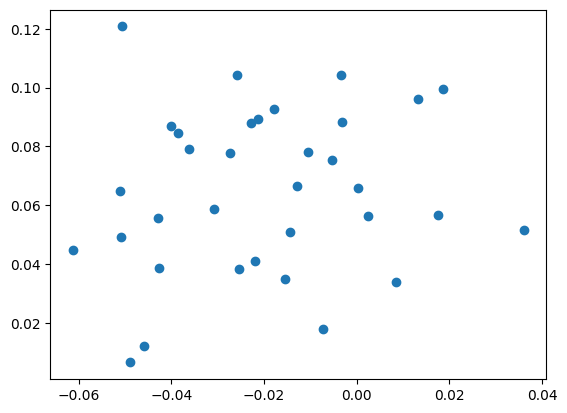

In [84]:
from matplotlib import pyplot as plt
import numpy as np

embeds = np.array(embeddings)

embeds.shape

plt.scatter(embeds[:,0], embeds[:,1])

In [ ]:
# Create ChromaDB vector store with persistence
import os
from langchain_chroma import Chroma

# Define the directory where ChromaDB will save the vector store
persist_directory = "./vectorstore"

print(f"Creating ChromaDB vector store with persistence at: {persist_directory}")

# Create the vector store with our chunks and embeddings
vectorstore = Chroma(
    collection_name="rsecon_schedule",
    embedding_function=ollama_embeddings,
    persist_directory=persist_directory,
)


Creating ChromaDB vector store with persistence at: ./vectorstore


In [ ]:
# Loading an existing ChromaDB vector store from disk
def load_existing_vectorstore(persist_directory: str = "./chromadb_storage", collection_name: str = "rag_demo"):
    """
    Load an existing ChromaDB vector store from disk.
    
    Args:
        persist_directory: Directory where the vector store is saved
        collection_name: Name of the collection to load
    
    Returns:
        Loaded Chroma vector store
    """
    if not os.path.exists(persist_directory):
        raise FileNotFoundError(f"Vector store directory not found: {persist_directory}")
    
    print(f"Loading existing vector store from: {persist_directory}")
    
    # Load the existing vector store
    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=embeddings,  # Must use the same embedding function
        collection_name=collection_name
    )
    
    print(f"✅ Loaded vector store with {vectorstore._collection.count()} documents")
    return vectorstore

# Example usage (commented out to avoid overwriting the current vectorstore):
# loaded_vectorstore = load_existing_vectorstore()
# print(f"Loaded vector store contains {loaded_vectorstore._collection.count()} documents")

print("💾 Vector store persistence is now enabled!")
print("You can now:")
print("1. Close this notebook and the vector store will remain saved")
print("2. Use load_existing_vectorstore() to reload it in future sessions")
print("3. Share the chromadb_storage folder to share your vector store")

## 4. Similarity Retrieval

Let's test the retrieval functionality with different queries and similarity thresholds.

In [ ]:
# Demonstrate similarity search
def test_similarity_search(query: str, k: int = 3):
    """Test similarity search with a given query"""
    print(f"\n🔍 Query: '{query}'")
    print(f"Retrieving top {k} similar documents:")
    print("-" * 50)
    
    # Similarity search
    results = vectorstore.similarity_search(query, k=k)
    
    for i, doc in enumerate(results, 1):
        source = doc.metadata.get('source', 'unknown')
        print(f"{i}. Source: {source}")
        print(f"   Content: {doc.page_content[:150]}...")
        print()
    
    return results

# Test with different queries
test_queries = [
    "What is machine learning?",
    "neural networks and deep learning",
    "How does RAG work?",
    "natural language processing applications"
]

for query in test_queries:
    test_similarity_search(query, k=2)

In [ ]:
# Demonstrate similarity search with scores
def test_similarity_search_with_scores(query: str, k: int = 3):
    """Test similarity search with similarity scores"""
    print(f"\n📊 Query with scores: '{query}'")
    print("-" * 50)
    
    # Similarity search with scores
    results = vectorstore.similarity_search_with_score(query, k=k)
    
    for i, (doc, score) in enumerate(results, 1):
        source = doc.metadata.get('source', 'unknown')
        print(f"{i}. Similarity Score: {score:.4f}")
        print(f"   Source: {source}")
        print(f"   Content: {doc.page_content[:100]}...")
        print()
    
    return results

# Test with scores
test_similarity_search_with_scores("What is deep learning?", k=15)

# Test retriever functionality
print("\n🔄 Testing retriever interface:")
retriever = vectorstore.as_retriever(search_kwargs={"k": 15})
retrieved_docs = retriever.get_relevant_documents("machine learning algorithms")

print(f"Retrieved {len(retrieved_docs)} documents using retriever interface")
for i, doc in enumerate(retrieved_docs, 1):
    print(f"{i}. {doc.page_content[:80]}...")

## 5. LLM Integration (OpenAI/Gemini/Ollama)

Now we'll set up flexible LLM integration that can work with different providers.

In [ ]:
# Configure different LLM providers
def get_llm(provider: str = "ollama", model: str = None):
    """
    Get LLM based on provider choice.
    Options: "openai", "ollama"
    """
    if provider == "openai":
        # Requires OPENAI_API_KEY environment variable
        model = model or "gpt-3.5-turbo"
        return ChatOpenAI(
            model=model,
            temperature=0.1,
            max_tokens=1000
        )
    
    elif provider == "ollama":
        # Requires Ollama to be running locally
        # Install: https://ollama.ai/
        # Run: ollama pull llama3.2:1b (or your preferred model)
        model = model or "llama3.2:1b"  # Using the lightweight 1B parameter model
        return OllamaLLM(
            model=model,
            temperature=0.1
        )
    
    else:
        raise ValueError(f"Unsupported provider: {provider}. Use 'openai' or 'ollama'")

## 6. Complete RAG Pipeline

Now let's put it all together into a complete RAG system!

In [ ]:
# Complete RAG Pipeline Class
class RAGPipeline:
    def __init__(self, embedding_provider="ollama", llm_provider="ollama", llm_model=None):
        """
        Initialize RAG pipeline with flexible provider options.
        
        Args:
            embedding_provider: "ollama" or "openai"
            llm_provider: "ollama" or "openai"  
            llm_model: Specific model name (optional)
        """
        self.embedding_provider = embedding_provider
        self.llm_provider = llm_provider
        
        # Initialize embeddings
        self.embeddings = get_embedding_model(embedding_provider)
        
        # Initialize LLM
        try:
            self.llm = get_llm(llm_provider, llm_model)
        except Exception as e:
            print(f"Warning: Could not initialize LLM ({llm_provider}): {e}")
            self.llm = None
        
        self.vectorstore = None
        self.retriever = None
        self.qa_chain = None
        
    def create_vectorstore(self, documents, collection_name="rag_collection", persist_directory=None):
        """
        Create ChromaDB vector store from documents.
        
        Args:
            documents: List of documents to embed
            collection_name: Name for the ChromaDB collection
            persist_directory: Directory to save the vector store (None for ephemeral)
        """
        print(f"Creating vector store with {len(documents)} documents...")
        
        if persist_directory:
            print(f"Vector store will be saved to: {persist_directory}")
            self.vectorstore = Chroma.from_documents(
                documents=documents,
                embedding=self.embeddings,
                collection_name=collection_name,
                persist_directory=persist_directory
            )
        else:
            print("Creating ephemeral (in-memory) vector store")
            self.vectorstore = Chroma.from_documents(
                documents=documents,
                embedding=self.embeddings,
                collection_name=collection_name
            )
        
        # Create retriever
        self.retriever = self.vectorstore.as_retriever(
            search_type="similarity",
            search_kwargs={"k": 3}
        )
        
        print(f"✅ Vector store created with {self.vectorstore._collection.count()} documents")
        return self.vectorstore
    
    def load_vectorstore(self, persist_directory, collection_name="rag_collection"):
        """
        Load an existing ChromaDB vector store from disk.
        
        Args:
            persist_directory: Directory where the vector store is saved
            collection_name: Name of the collection to load
        """
        if not os.path.exists(persist_directory):
            raise FileNotFoundError(f"Vector store directory not found: {persist_directory}")
        
        print(f"Loading existing vector store from: {persist_directory}")
        
        self.vectorstore = Chroma(
            persist_directory=persist_directory,
            embedding_function=self.embeddings,
            collection_name=collection_name
        )
        
        # Create retriever
        self.retriever = self.vectorstore.as_retriever(
            search_type="similarity",
            search_kwargs={"k": 3}
        )
        
        print(f"✅ Loaded vector store with {self.vectorstore._collection.count()} documents")
        return self.vectorstore
    
    def setup_qa_chain(self):
        """Set up the question-answering chain."""
        if not self.llm:
            raise ValueError("LLM not available. Please configure an LLM provider.")
        
        if not self.retriever:
            raise ValueError("Retriever not available. Please create vector store first.")
        
        # Custom prompt template
        prompt_template = """Use the following pieces of context to answer the question at the end. 
        If you don't know the answer, just say that you don't know, don't try to make up an answer.

        Context:
        {context}

        Question: {question}
        
        Answer:"""
        
        PROMPT = PromptTemplate(
            template=prompt_template,
            input_variables=["context", "question"]
        )
        
        # Create QA chain
        self.qa_chain = RetrievalQA.from_chain_type(
            llm=self.llm,
            chain_type="stuff",
            retriever=self.retriever,
            chain_type_kwargs={"prompt": PROMPT},
            return_source_documents=True
        )
        
        print("✅ QA chain configured")
        return self.qa_chain
    
    def query(self, question: str, return_sources: bool = True):
        """Query the RAG system."""
        if not self.qa_chain:
            raise ValueError("QA chain not configured. Please run setup_qa_chain() first.")
        
        print(f"\n🤖 Question: {question}")
        print("-" * 50)
        
        result = self.qa_chain({"query": question})
        
        answer = result["result"]
        sources = result.get("source_documents", [])
        
        print(f"Answer: {answer}")
        
        if return_sources and sources:
            print(f"\n📚 Sources ({len(sources)} documents):")
            for i, doc in enumerate(sources, 1):
                source = doc.metadata.get('source', 'unknown')
                print(f"{i}. {source}: {doc.page_content[:100]}...")
        
        return {
            "question": question,
            "answer": answer,
            "sources": sources
        }

# Initialize the RAG pipeline
rag = RAGPipeline(
    embedding_provider="ollama",  # Local Ollama embeddings
    llm_provider="ollama",  # Change to "openai" if you have API key
    llm_model="llama3.2:1b"  # Using the lightweight 1B parameter model
)


In [ ]:
# Set up the complete RAG system with persistence
print("Setting up complete RAG system with persistent storage...")

# Create vector store with our chunks and save to disk
rag.create_vectorstore(
    documents=all_chunks, 
    collection_name="ai_knowledge_base",
    persist_directory="./rag_vectorstore"  # Save to disk
)

rag.setup_qa_chain()

print("💾 RAG system is now set up with persistent storage!")
print("The vector store is saved to './rag_vectorstore' directory")

# Alternative: Load existing vector store instead of creating new one
# Uncomment the following lines if you want to load an existing vector store:
# 
# rag.load_vectorstore(
#     persist_directory="./rag_vectorstore",
#     collection_name="ai_knowledge_base"
# )
# rag.setup_qa_chain()

In [ ]:
# Test the complete RAG system
if rag.llm and rag.qa_chain:
    print("🧪 Testing complete RAG pipeline...")
    
    # Test queries
    test_questions = [
        "What is machine learning?",
        "How does deep learning differ from traditional machine learning?", 
        "What are the main applications of NLP?",
        "Explain how RAG works"
        "What is rsecon25?"
    ]
    
    for question in test_questions:
        try:
            result = rag.query(question)
            print("\n" + "="*60 + "\n")
        except Exception as e:
            print(f"Error processing question '{question}': {e}")
            break
            
else:
    print("🔍 Testing retrieval functionality only...")
    
    # Test retrieval without LLM
    if rag.retriever:
        test_questions = [
            "What is machine learning?",
            "deep learning neural networks",
            "natural language processing"
        ]
        
        for question in test_questions:
            print(f"\n🔍 Retrieving for: '{question}'")
            docs = rag.retriever.get_relevant_documents(question)
            for i, doc in enumerate(docs, 1):
                source = doc.metadata.get('source', 'unknown')
                print(f"{i}. {source}: {doc.page_content[:100]}...")
            print("-" * 40)